<h3 style="color:white; text-align:center;">23CSE301 Machine Learning -Capstone Project</h3>
<p style="color:white; text-align:center;"><strong>Track 2: Classification - FIFA World Cup 2026 </strong></p>

<h4>Review 1 Classification Algorithms:</h4>
<ol>
    <li>Logistic Regression</li><li>K-Nearest Neighbors</li>
    <li>Naive Bayes</li><li>Decision Tree</li><li>Support Vector Machine(SVC)</li>
</ol>
<hr>

<h3>Environment Setup & Library Imports</h3>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import (
RandomForestClassifier,AdaBoostClassifier,
GradientBoostingClassifier,BaggingClassifier
)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
accuracy_score,precision_score,recall_score,f1_score,
confusion_matrix,classification_report,roc_auc_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')
# Set Plot Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
print("All libraries imported imported successfuly")

All libraries imported imported successfuly


<h3 style="text-align:center;">A1 - Dataset Loading & Audit</h3>

In [8]:
df = pd.read_csv(r"C:\Users\manoh\Downloads\SEM5\Machine Learning\ML-Algorithms\data\classification\classification.csv")

print(f"Dataset Shape: {df.shape}\n")
print(f"Data Types :\n{df.dtypes}\n")
print("Missing Values :")
missing = df.isnull().sum()
print(f"Columns with missing values: {(missing > 0).sum()}")
if (missing > 0).sum() > 0:
    print(missing[missing>0])
else:
    print("No missing values present")    
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nClass proportions:")
print(df['position'].value_counts(normalize=True).round(4))

Dataset Shape: (54600, 75)

Data Types :
player_id                    object
player_name                  object
age                           int64
nationality                  object
team                         object
                             ...   
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
tournament_rating           float64
Length: 75, dtype: object

Missing Values :
Columns with missing values: 0
No missing values present
Duplicate rows: 0

Class proportions:
position
Defender      0.3462
Midfielder    0.3077
Forward       0.2308
Goalkeeper    0.1154
Name: proportion, dtype: float64


In [9]:
print(df['position'].describe())

count        54600
unique           4
top       Defender
freq         18900
Name: position, dtype: object


<h3 style="text-align:center;">A2 - EDA visualizations</h3>
<h4>Target Variable Distribution</h4>
<p>Target variable : Position has 4 classes so, let's get into visualization part</p>

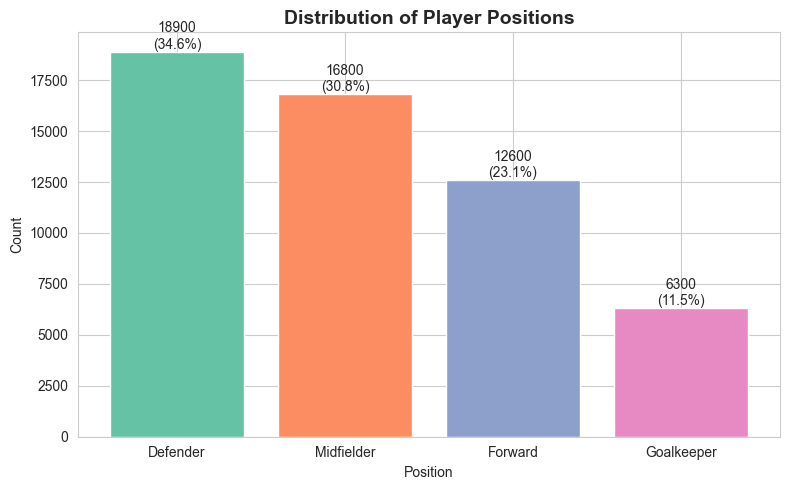

Observation: The dataset is imbalanced — Defenders are the most represented (34.6%), while Goalkeepers are the least (11.5%). This means we should use stratified splitting and weighted metrics for fair evaluation.


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
position_counts = df['position'].value_counts()
bars = ax.bar(position_counts.index, position_counts.values,
              color=sns.color_palette('Set2', len(position_counts)))
ax.set_title('Distribution of Player Positions', fontsize=14, fontweight='bold')
ax.set_xlabel('Position')
ax.set_ylabel('Count')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}\n({height/len(df)*100:.1f}%)',
           ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('eda_target_distribution.png', bbox_inches='tight')
plt.show()
print("Observation: The dataset is imbalanced — Defenders are the most represented (34.6%), "
      "while Goalkeepers are the least (11.5%). This means we should use stratified splitting "
      "and weighted metrics for fair evaluation.")


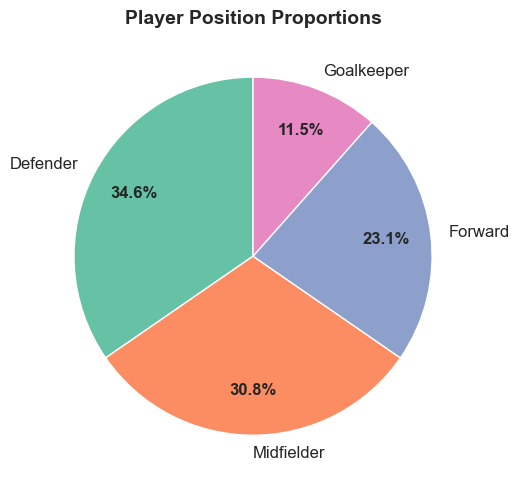

Observation: The pie chart gives a quick visual sense of class imbalance. Defenders (34.6%) and Midfielders (30.8%) dominate, while Goalkeepers (11.5%) are underrepresented — important context for choosing stratified splitting and weighted evaluation metrics.


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
position_counts = df['position'].value_counts()
colors = sns.color_palette('Set2', len(position_counts))
wedges, texts, autotexts = ax.pie(
    position_counts.values, labels=position_counts.index,
    autopct='%1.1f%%', startangle=90, colors=colors,
    textprops={'fontsize': 12}, pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax.set_title('Player Position Proportions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_position_piechart.png', bbox_inches='tight')
plt.show()
print("Observation: The pie chart gives a quick visual sense of class imbalance. "
      "Defenders (34.6%) and Midfielders (30.8%) dominate, while Goalkeepers (11.5%) "
      "are underrepresented — important context for choosing stratified splitting "
      "and weighted evaluation metrics.")
